In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# df = pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')
# df.head()

In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [ ]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [ ]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [ ]:
from sklearn.preprocessing import LabelEncoder
lr = LabelEncoder()
df['Geography_Germany'] = lr.fit_transform(df['Geography_Germany'])
df['Geography_Spain'] = lr.fit_transform(df['Geography_Spain'])
df['Gender_Male'] = lr.fit_transform(df['Gender_Male'])
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited']
X.shape

(10000, 11)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=1,test_size=0.2)
X_train.shape

(8000, 11)

In [ ]:
from sklearn.preprocessing import StandardScaler
sca = StandardScaler()
X_train_scaled = sca.fit_transform(X_train)
X_test_scaled  = sca.transform(X_test)

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(11,activation='relu',input_dim=11)) # model with one hidden layer which has 3 nodes
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid')) # output layer with one node

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss = 'binary_crossentropy',optimizer = 'Adam',metrics=['accuracy'])

In [ ]:
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6111 - loss: 0.6639 - val_accuracy: 0.7975 - val_loss: 0.4869
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7981 - loss: 0.4710 - val_accuracy: 0.8144 - val_loss: 0.4412
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8058 - loss: 0.4421 - val_accuracy: 0.8125 - val_loss: 0.4282
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8259 - loss: 0.4113 - val_accuracy: 0.8188 - val_loss: 0.4195
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8209 - loss: 0.4114 - val_accuracy: 0.8244 - val_loss: 0.4111
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8265 - loss: 0.4012 - val_accuracy: 0.8263 - val_loss: 0.4038
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8275 - loss: 0.3985 - val_accuracy: 0.8263 - val_loss: 0.3968
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8362 - loss: 0.3903 - val_accu

In [ ]:
model.layers[0].get_weights()

[array([[-0.251591  , -0.17580293, -0.07382404,  0.3467487 ,  0.02863461,
          0.10465936,  0.08057462,  0.16470404,  0.23062013, -0.05967828,
         -0.7453898 ],
        [ 1.0655973 , -0.05431046,  0.9897989 ,  0.480514  , -0.5582812 ,
         -0.48509383, -0.07990573,  0.2797013 ,  0.13041766, -0.09727406,
          0.20984982],
        [-0.0821027 , -0.01773695, -0.19889088,  0.10775045,  0.07583799,
         -0.35654825,  0.06768765, -0.08552517, -0.00825217, -0.07243644,
         -0.60482895],
        [-0.33699396,  0.2854331 ,  0.05415516, -0.1441411 , -0.07104808,
         -0.03112387, -0.54239374,  0.12013277,  0.12893717, -0.7791337 ,
         -0.1283805 ],
        [-0.04073684, -0.47857472, -0.38420233, -0.11743322, -0.28284064,
         -0.07862939, -0.26111305,  1.0129603 , -1.1521984 , -1.1507503 ,
         -0.07423318],
        [ 0.22314502, -0.07283085, -0.01499111, -0.3112162 ,  0.2654513 ,
         -0.1435344 ,  0.09688186, -0.12229918, -0.09438369, -0.0174853

In [ ]:
model.layers[1].get_weights()

[array([[-0.02840421,  0.41633922, -0.22241236, -0.6570436 , -0.8966468 ,
          0.37706214, -0.35512698,  0.11857244,  0.3009907 , -0.28025013,
         -0.6217644 ],
        [ 0.13469313, -0.16366087,  0.17532156,  0.11148051,  0.31012166,
         -0.37989712,  0.13144326,  0.14259605,  0.0702638 ,  0.25647244,
          0.24432115],
        [ 0.1503058 ,  0.16096352,  0.21911952, -0.56779736, -0.3606019 ,
          0.590308  , -0.00670735,  0.6172652 , -0.181177  , -0.7719496 ,
         -0.5463134 ],
        [ 0.16342027,  0.553901  ,  0.11560956,  0.12362994,  0.46929002,
          0.44706765,  0.4251364 ,  0.28205547,  0.62443554, -0.01819979,
         -0.0127667 ],
        [ 0.2967437 ,  0.39441434,  0.6238753 ,  0.43083853,  0.20303424,
          0.24391367, -0.79207134,  0.02350655,  0.40119812,  0.37013155,
         -0.12168337],
        [-0.30583012, -0.6655826 , -0.39734125,  0.08599549, -0.405473  ,
          0.05815623, -1.1495801 ,  0.2161031 , -0.10772365,  0.3757724

In [ ]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [ ]:
y_pred = np.where(y_log>0.5,1,0)

In [ ]:
from sklearn.metrics import accuracy_score
print("acc:",accuracy_score(y_test,y_pred))

acc: 0.8645


In [ ]:
# history.history

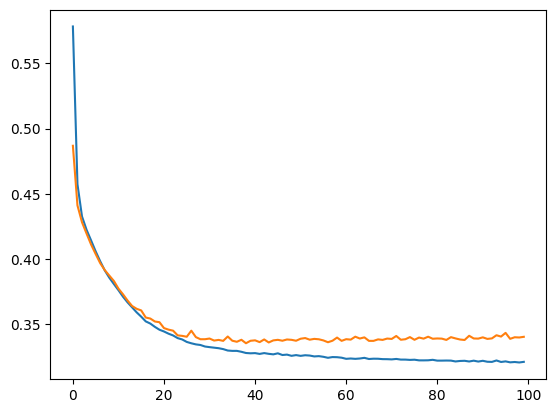

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

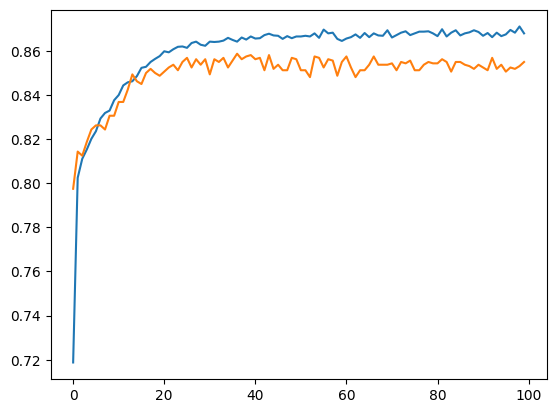

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])